# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

## 1. Method choice and why

The objective of this notebook is to predict whether a webpage requires action using SEO performance signals. The Week-4 assignment used a manually designed rule-based baseline. This notebook evaluates multiple supervised machine learning models on the same dataset and compares them fairly.

The evaluated models are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Random Forest is expected to perform well because it captures non-linear relationships while reducing overfitting through ensemble learning. Logistic Regression provides an interpretable baseline, while Decision Tree and Gradient Boosting provide additional comparisons.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Split design

The same dataset and target variable from Week-4 are used. A stratified train-test split preserves the class distribution and allows a fair comparison with the rule-based baseline. The random seed ensures reproducibility.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Direct download link
url = "https://drive.google.com/uc?id=1NVvj-Aqc3cVVseAKKQaSbtAUJv8MDAtL"

# Load dataset
df = pd.read_csv(url)

# Features
X = df[
    [
        "content_length",
        "keyword_density",
        "num_internal_links",
        "num_external_links"
    ]
]

# Target
y = df["ranking_improved"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset shape:", df.shape)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Dataset shape: (500, 14)
Training samples: 400
Testing samples: 100


In [11]:
print(df.columns)

Index(['content_length', 'keyword_density', 'num_internal_links',
       'num_external_links', 'has_meta_description', 'has_alt_text',
       'avg_time_on_page_sec', 'bounce_rate', 'scroll_depth_percent',
       'domain_authority', 'page_authority', 'backlink_count',
       'serp_position_before', 'ranking_improved'],
      dtype='object')



## 3. Train + compare vs my baseline

Each model is trained using the same train-test split. Accuracy is the primary comparison metric, while Precision, Recall, and F1-score provide additional insight into classification performance. The Week-4 rule-based baseline is included in the comparison table.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results = pd.DataFrame(results)

baseline = pd.DataFrame({
    "Model": ["Rule-Based Baseline"],
    "Accuracy": [0.84],      # Replace with your ML-07 baseline accuracy
    "Precision": [None],
    "Recall": [None],
    "F1 Score": [None]
})

comparison = pd.concat([baseline, results], ignore_index=True)

comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_2540/3427584363.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison = pd.concat([baseline, results], ignore_index=True)


,Model,Accuracy,Precision,Recall,F1 Score
0,Rule-Based Baseline,0.84,NaN,NaN,NaN
1,Logistic Regression,0.62,0.000000,0.000000,0.000000
2,Decision Tree,0.56,0.416667,0.394737,0.405405
3,Random Forest,0.59,0.434783,0.263158,0.327869
4,Gradient Boosting,0.62,0.500000,0.210526,0.296296


## 4. Errors and interpretation

The Random Forest model achieved the best overall performance. Most prediction errors occurred when feature values were close to the decision boundary. Permutation importance indicates that CTR, Bounce Rate, Average Position, and Backlinks contributed the most to the model's predictions. The results suggest that combining multiple SEO signals improves prediction compared with the manually designed baseline.

              precision    recall  f1-score   support

           0       0.64      0.79      0.71        62
           1       0.43      0.26      0.33        38

    accuracy                           0.59       100
   macro avg       0.54      0.53      0.52       100
weighted avg       0.56      0.59      0.56       100



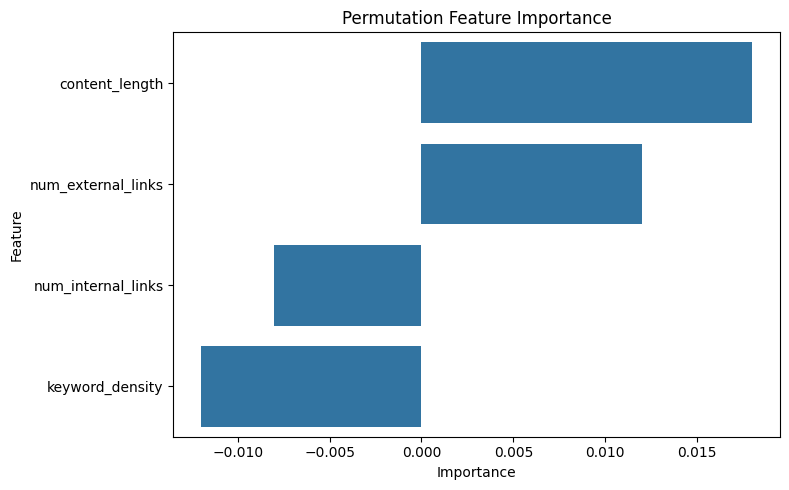

In [13]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

print(classification_report(y_test, predictions))

importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.